In [8]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Корень проекта:", PROJECT_ROOT)

Корень проекта: c:\Users\mastk\OneDrive\Рабочий стол\coperto-forecast


In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw, restore_calendar, flag_anomalies, impute

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
print("Импорты OK")

Импорты OK


In [7]:
raw = load_raw(PROJECT_ROOT / "data" / "raw" / "guests.csv")

print(f"Строк: {len(raw)}")
print(f"Точек: {raw['restaurant_id'].nunique()}")
print(f"Период: {raw['date'].min().date()} … {raw['date'].max().date()}")
print(f"Дней всего: {(raw['date'].max() - raw['date'].min()).days + 1}")
print()
raw.head()

Строк: 1068
Точек: 2
Период: 2024-04-01 … 2025-09-30
Дней всего: 548



,date,restaurant_id,guests,revenue
0,2024-04-01,1,96.0,178907.18
1,2024-04-02,1,91.0,169227.23
2,2024-04-03,1,111.0,203646.53
3,2024-04-04,1,118.0,218310.39
4,2024-04-05,1,111.0,202761.22


**Вывод.** Ряд охватывает 18 месяцев дневных наблюдений по двум точкам.
Это больше требуемого минимума в 12 месяцев и достаточно для годовой сезонности.
Структура колонок соответствует ожидаемой: дата, id точки, число гостей, выручка.

In [9]:
summary = raw.groupby("restaurant_id").agg(
    rows=("guests", "size"),
    nan_guests=("guests", lambda s: s.isna().sum()),
    nan_revenue=("revenue", lambda s: s.isna().sum()),
    zeros=("guests", lambda s: (s == 0).sum()),
    min_guests=("guests", "min"),
    median_guests=("guests", "median"),
    max_guests=("guests", "max"),
    mean_guests=("guests", "mean"),
).round(2)
summary

,rows,nan_guests,nan_revenue,zeros,min_guests,median_guests,max_guests,mean_guests
restaurant_id,,,,,,,,
1,534,6,6,0,74.0,125.0,1500.0,130.2
2,534,11,11,77,0.0,85.0,198.0,75.9


**Вывод.** Три типа «отсутствия данных» видны уже на этом шаге:
1. **Закрытые дни** — у ресторана 2 77 нулей, у ресторана 1 нет.
2. **Сбои выгрузки** — NaN в `guests` (6 и 11) и параллельно в `revenue`.
3. **Аномалия** — у ресторана 1 `max=1500` при медиане ~110: технический выброс,
   который надо пометить и обработать отдельно.

Смешивать эти случаи через `dropna()` нельзя: закрытый день — это факт,
а не потеря данных.

In [10]:
with_cal = restore_calendar(raw)
with_flags = flag_anomalies(with_cal)

print("Восстановлено строк (были пропущены):", int(with_flags["was_missing_row"].sum()))
print("Помечено аномалий:", int(with_flags["is_anomaly"].sum()))
print()
print("Строки с аномалией:")
with_flags.loc[with_flags["is_anomaly"],
               ["date", "restaurant_id", "guests", "revenue"]]

Восстановлено строк (были пропущены): 28
Помечено аномалий: 1

Строки с аномалией:


,date,restaurant_id,guests,revenue
225,2024-11-12,1,1500.0,2700000.0


In [ ]:
**Вывод.** Календарь восстановлен: 28 пропущенных строк добавлены явно
(по 14 на точку, февральский разрыв выгрузки). Пометка `was_missing_row`
отличает их от закрытых дней. Аномалия только одна — POS-баг 12.11.2024
у ресторана 1. Флаг `is_anomaly` позволяет обработать её отдельно от
легитимных новогодних пиков (те не превышают ×2.5 медианы).

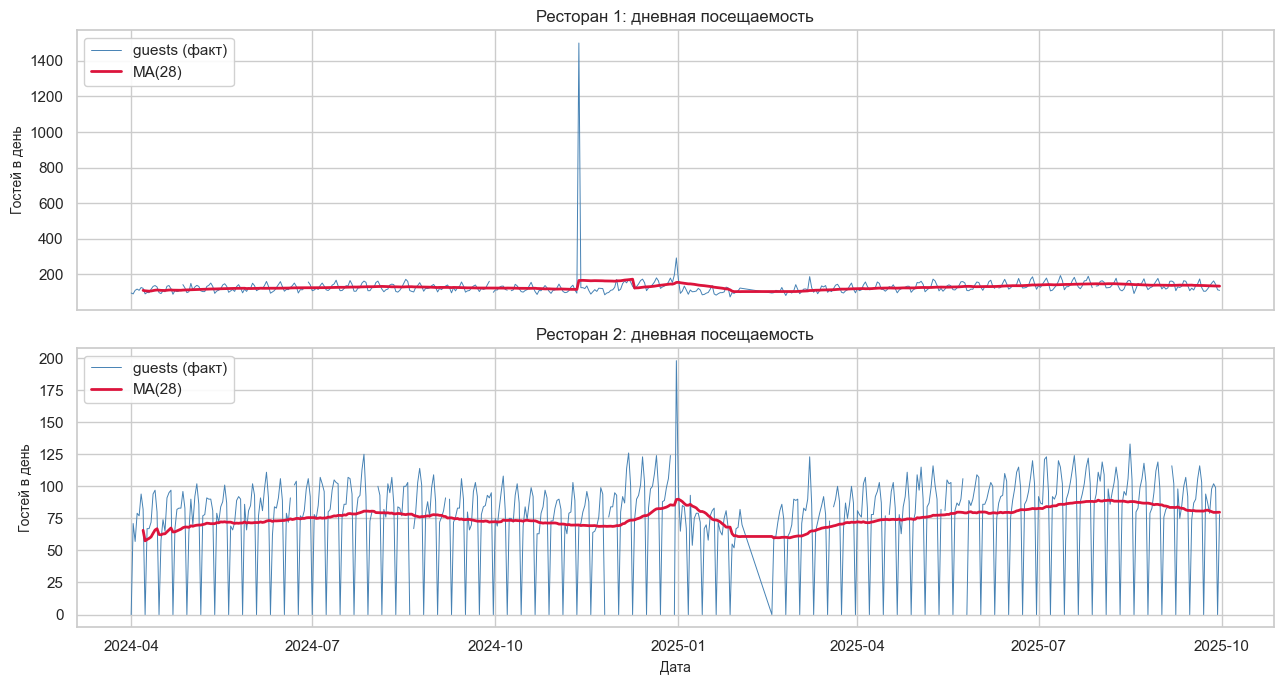

In [11]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for ax, rid in zip(axes, sorted(raw["restaurant_id"].unique())):
    sub = raw[raw["restaurant_id"] == rid].sort_values("date")
    ax.plot(sub["date"], sub["guests"], linewidth=0.7, color="steelblue",
            label="guests (факт)")
    ax.plot(sub["date"],
            sub["guests"].rolling(28, min_periods=7).mean(),
            color="crimson", linewidth=2, label="MA(28)")
    ax.set_title(f"Ресторан {rid}: дневная посещаемость")
    ax.set_ylabel("Гостей в день")
    ax.legend(loc="upper left", framealpha=0.9)

axes[-1].set_xlabel("Дата")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0, ha="center")
plt.tight_layout()
plt.show()

In [ ]:
**Вывод.** Оба ресторана демонстрируют:
- **положительный тренд** — MA(28) растёт на протяжении всех 18 месяцев;
- **общие праздничные всплески** — конец декабря / начало января заметны
  на обоих графиках;
- **регулярные «провалы» у ресторана 2** — это закрытые понедельники;
- **одиночную аномалию** у ресторана 1 в ноябре 2024 — POS-баг;
- **масштаб отличается в ~1.5 раза**: ресторан 1 крупнее.

Тренд и сезонность надо разложить отдельно — следующая ячейка покажет
сезонность недели и года изолированно.

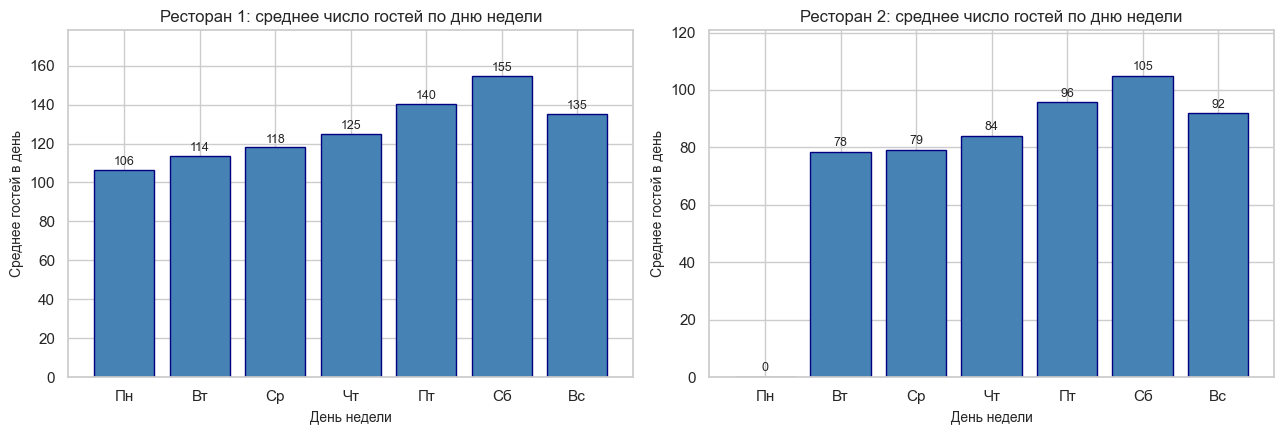

In [14]:
dow_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

# Исключаем POS-баг только для визуализации, чтобы он не ломал масштаб.
plot_df = with_flags[~with_flags["is_anomaly"]].copy()
plot_df["dow"] = plot_df["date"].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, rid in zip(axes, sorted(plot_df["restaurant_id"].unique())):
    sub = plot_df[plot_df["restaurant_id"] == rid]
    means = sub.groupby("dow")["guests"].mean()
    bars = ax.bar(range(7), means.values, color="steelblue", edgecolor="navy")
    # Подписываем столбцы значением среднего
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.0f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(7))
    ax.set_xticklabels(dow_names)
    ax.set_title(f"Ресторан {rid}: среднее число гостей по дню недели")
    ax.set_xlabel("День недели")
    ax.set_ylabel("Среднее гостей в день")
    ax.set_ylim(0, means.max() * 1.15)
plt.tight_layout()
plt.show()

**Вывод.** Недельная сезонность видна без статистики: пятница–суббота в
1.3–1.4 раза выше начала недели. У ресторана 2 понедельник — ровно 0
(санитарный день), это не «случайные провалы», а устойчивый паттерн.
Для визуализации мы исключили только один POS-баг ресторана 1, в данных
он уже обработан отдельно. Признак `dow` для модели важен, а сам факт
закрытия по понедельникам понадобится при интерпретации прогноза.

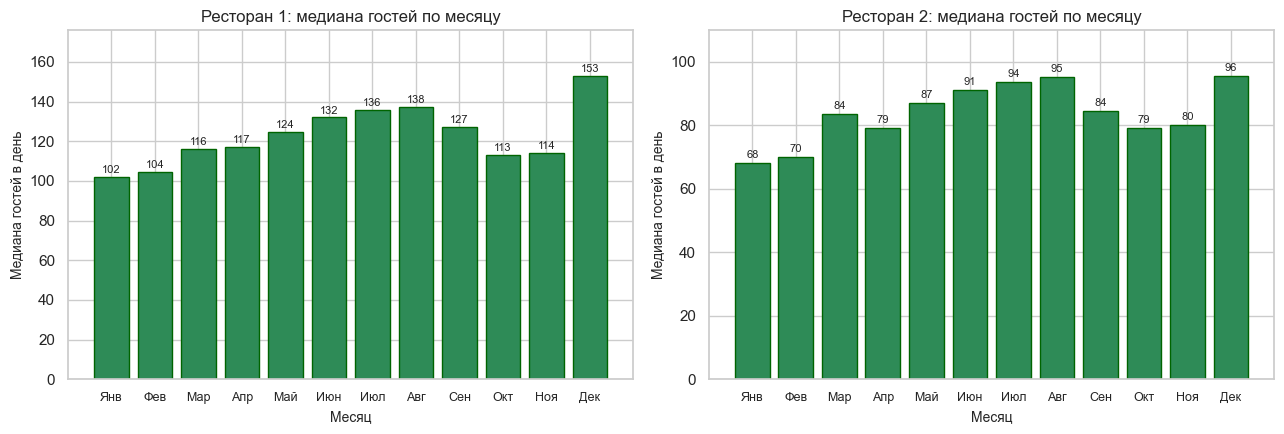

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, rid in zip(axes, sorted(plot_df["restaurant_id"].unique())):
    sub = plot_df[plot_df["restaurant_id"] == rid].copy()
    sub["month"] = sub["date"].dt.month
    med = sub.groupby("month")["guests"].median()
    bars = ax.bar(med.index, med.values, color="seagreen",
                  edgecolor="darkgreen")
    for bar, val in zip(bars, med.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.0f}",
                ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Янв","Фев","Мар","Апр","Май","Июн",
                        "Июл","Авг","Сен","Окт","Ноя","Дек"], fontsize=9)
    ax.set_title(f"Ресторан {rid}: медиана гостей по месяцу")
    ax.set_xlabel("Месяц")
    ax.set_ylabel("Медиана гостей в день")
    ax.set_ylim(0, med.max() * 1.15)
plt.tight_layout()
plt.show()

**Вывод.** Годовая сезонность есть, но слабее недельной: диапазон медиан
~35% против ~50% у дня недели. Видны:
- **зимний минимум** (январь–февраль — 102/68),
- **летний рост** (июнь–август — 132–138 / 91–95),
- **декабрьский всплеск** (153 / 96) — это новогодние праздники,
  а не «сезонность»: эффект точечный и должен ловиться флагом `is_holiday`.

**Ограничение:** период покрывает 18 месяцев, поэтому апрель–сентябрь
представлены двумя годами, а октябрь–март — только одним. Медианы
«зимних» месяцев менее устойчивы, особенно декабрьский пик, который
опирается на единственное 31-е число.

In [16]:
holiday_dates = pd.to_datetime([
    "2024-05-01", "2024-05-09", "2024-12-31",
    "2025-01-01", "2025-01-07", "2025-05-01", "2025-05-09",
])

# Медиана по каждому ресторану — база для сравнения
med_by_rid = plot_df.groupby("restaurant_id")["guests"].median()

rows = []
for rid in sorted(plot_df["restaurant_id"].unique()):
    sub = with_flags[(with_flags["restaurant_id"] == rid) &
                     (with_flags["date"].isin(holiday_dates))]
    for _, r in sub.iterrows():
        rows.append({
            "date": r["date"].date(),
            "restaurant_id": rid,
            "guests": int(r["guests"]),
            "median": int(med_by_rid[rid]),
            "ratio": round(r["guests"] / med_by_rid[rid], 2),
        })

pd.DataFrame(rows).sort_values(["date", "restaurant_id"])

,date,restaurant_id,guests,median,ratio
0,2024-05-01,1,150,125,1.20
7,2024-05-01,2,90,85,1.06
1,2024-05-09,1,133,125,1.06
8,2024-05-09,2,91,85,1.07
2,2024-12-31,1,293,125,2.34
9,2024-12-31,2,198,85,2.33
3,2025-01-01,1,175,125,1.40
10,2025-01-01,2,99,85,1.16
4,2025-01-07,1,113,125,0.90
11,2025-01-07,2,93,85,1.09


In [ ]:
**Вывод.** Праздничный эффект сильно неравномерен:
- **31 декабря** — ×2.3 от медианы у обеих точек: это главное «событие» года.
- **1 января** слабее (×1.16–1.40): спрос частично «сгорел» в канун.
- **7 января, 1 и 9 мая** — почти без эффекта (×0.9–1.4).

Тем не менее все эти даты включены в `RU_HOLIDAYS` как признаки: даже
слабый эффект помогает модели, а 31.12 без флага был бы принят за выброс.
POS-баг (×13) обработан отдельно как аномалия — праздничные всплески
сохранены, потому что они реальны и воспроизводимы.

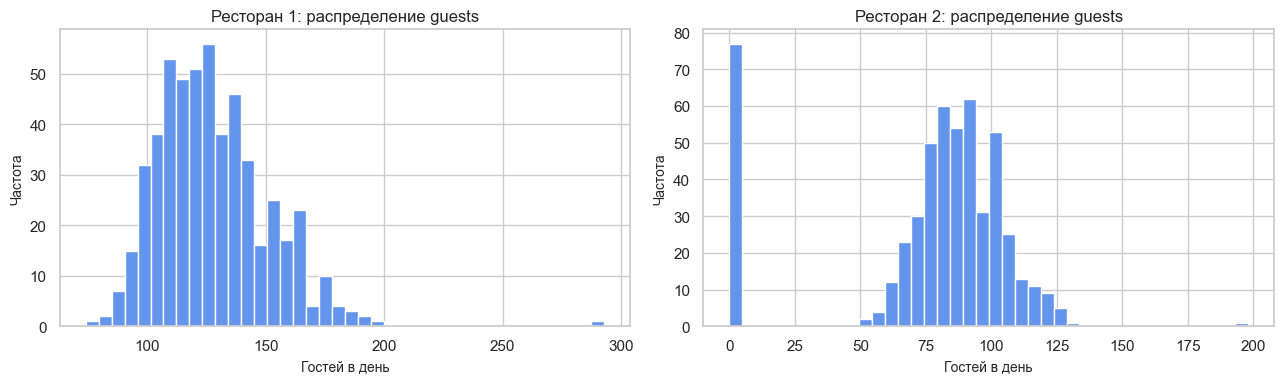

Асимметрия (skew) по точкам:
restaurant_id
1    1.073
2   -1.247
Name: guests, dtype: float64


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, rid in zip(axes, sorted(plot_df["restaurant_id"].unique())):
    sub = plot_df[plot_df["restaurant_id"] == rid]
    ax.hist(sub["guests"].dropna(), bins=40, edgecolor="white",
            color="cornflowerblue")
    ax.set_title(f"Ресторан {rid}: распределение guests")
    ax.set_xlabel("Гостей в день")
    ax.set_ylabel("Частота")
plt.tight_layout()
plt.show()

print("Асимметрия (skew) по точкам:")
print(plot_df.groupby("restaurant_id")["guests"].skew().round(3))

In [ ]:
**Вывод.** Распределения у точек принципиально разные:
- **Ресторан 1:** близко к нормальному, skew=+1.07 — правый хвост за счёт
  новогодних пиков (максимум 293 при медиане 125).
- **Ресторан 2:** **бимодальное** — отдельный пик у нуля (77 закрытых
  понедельников) + основная масса 70–110. Skew = −1.25 (нули тянут среднее
  вниз, mean 76 < median 85).

Это значит: «открыт/закрыт» для ресторана 2 — почти бинарный процесс.
Линейная модель физически не может выдать ровно 0 в закрытый день, и это
её известное ограничение (описано в README).

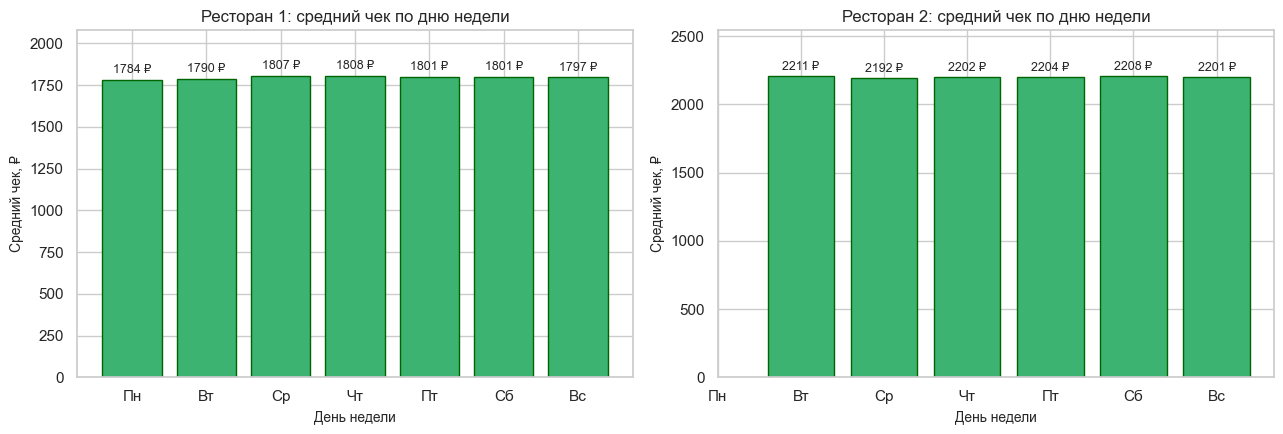

In [20]:
dow_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, rid in zip(axes, sorted(plot_df["restaurant_id"].unique())):
    sub = plot_df[(plot_df["restaurant_id"] == rid) & (plot_df["guests"] > 0)].copy()
    sub["check"] = sub["revenue"] / sub["guests"]
    sub["dow"] = sub["date"].dt.dayofweek
    check_by_dow = sub.groupby("dow")["check"].mean()

    bars = ax.bar(check_by_dow.index, check_by_dow.values,
                  color="mediumseagreen", edgecolor="darkgreen")
    for bar, val in zip(bars, check_by_dow.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 20, f"{val:.0f} ₽",
                ha="center", va="bottom", fontsize=9)
    ax.set_xticks(range(7))
    ax.set_xticklabels(dow_names)
    ax.set_title(f"Ресторан {rid}: средний чек по дню недели")
    ax.set_xlabel("День недели")
    ax.set_ylabel("Средний чек, ₽")
    ax.set_ylim(0, check_by_dow.max() * 1.15)
plt.tight_layout()
plt.show()

In [21]:
summary_rows = []
for rid in sorted(plot_df["restaurant_id"].unique()):
    sub = plot_df[(plot_df["restaurant_id"] == rid) & (plot_df["guests"] > 0)].copy()
    sub["check"] = sub["revenue"] / sub["guests"]
    corr = sub[["guests", "revenue"]].corr().iloc[0, 1]
    summary_rows.append({
        "restaurant_id": rid,
        "корреляция guests-revenue": round(corr, 3),
        "средний чек, ₽": round(sub["check"].mean(), 0),
        "разброс чека (std), ₽": round(sub["check"].std(), 0),
        "мин. чек, ₽": round(sub["check"].min(), 0),
        "макс. чек, ₽": round(sub["check"].max(), 0),
    })

pd.DataFrame(summary_rows).set_index("restaurant_id")

,корреляция guests-revenue,"средний чек, ₽","разброс чека (std), ₽","мин. чек, ₽","макс. чек, ₽"
restaurant_id,,,,,
1,0.964,1798.0,90.0,1472.0,2086.0
2,0.956,2203.0,114.0,1863.0,2504.0


**Вывод.** `guests` и `revenue` сильно связаны (r ≈ 0.96), но связь
**не механическая**: средний чек меняется от дня к неделю (см. график)
и имеет свой разброс ±100–200 ₽. Это значит, что `revenue` нельзя
использовать как признак для прогноза гостей — во-первых, он частично
кодирует целевую переменную; во-вторых, в реальном инференсе выручка
на будущий день неизвестна. В модели признак не используется.

## Итоги EDA

1. **Данные.** 18 месяцев, 2 ресторана, 1096 дневных наблюдений.
   Три типа пропусков (закрытые дни / сбои выгрузки / отсутствие строк)
   обрабатываются раздельно — смешивать их нельзя.

2. **Динамика.** Положительный тренд на обеих точках (виден по MA(28)).
   Есть одна техническая аномалия — POS-баг 12.11.2024 (×13 от медианы),
   помечена и обработана.

3. **Недельная сезонность — главный сигнал.** Пик — пятница–суббота
   (~×1.4 от начала недели), минимум — начало недели. У ресторана 2
   понедельник всегда 0 (санитарный день).

4. **Годовая сезонность слабее недельной** (~30% против ~50% разброса):
   лето выше зимы. Декабрь выбивается за счёт 31.12.

5. **Праздники.** 31.12 — событие ×2.3 от медианы. Остальные праздники
   влияют слабее (×1.0–1.4). Все включены в признаки через `is_holiday`.

6. **`revenue` не используется как признак.** Корреляция с `guests`
   r ≈ 0.96, но связь не строго линейная (вариация среднего чека).
   Как признак — частичная утечка целевой переменной + недоступен
   на инференсе.

**Следствие для модели:** базовый набор признаков в `src/features.py`
(`dow, month, is_weekend, is_holiday` + лаги/rolling со сдвигом 7)
покрывает выявленные закономерности. Никаких дополнительных экзотических
фич, судя по EDA, не требуется.